In [307]:
import numpy as np
import matplotlib.pyplot as plt

# core-in-core plots

In [308]:
filename = '/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model100/time_evolution.txt'
data = np.genfromtxt(filename, names=True)

dict = {name: data[name] for name in data.dtype.names}
t = dict['time']
rho_c = dict['rho_c']

In [309]:
import glob
import os

filename = '/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model100/profile_0.dat'
data = np.genfromtxt(filename, names=True)

dict = {name: data[name] for name in data.dtype.names}
r_i = 10**dict['log_rmid']
rho_i = dict['rho']
v2_i = dict['v2']

# Find all profile files and get the one with the highest number
profile_files = glob.glob('/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model100/profile_*.dat')
latest_profile = max(profile_files, key=lambda x: int(x.split('profile_')[1].split('.dat')[0]))
filename = latest_profile
data = np.genfromtxt(filename, names=True)

dict = {name: data[name] for name in data.dtype.names}
r_f = 10**dict['log_rmid']
rho_f = dict['rho']
v2_f = dict['v2']


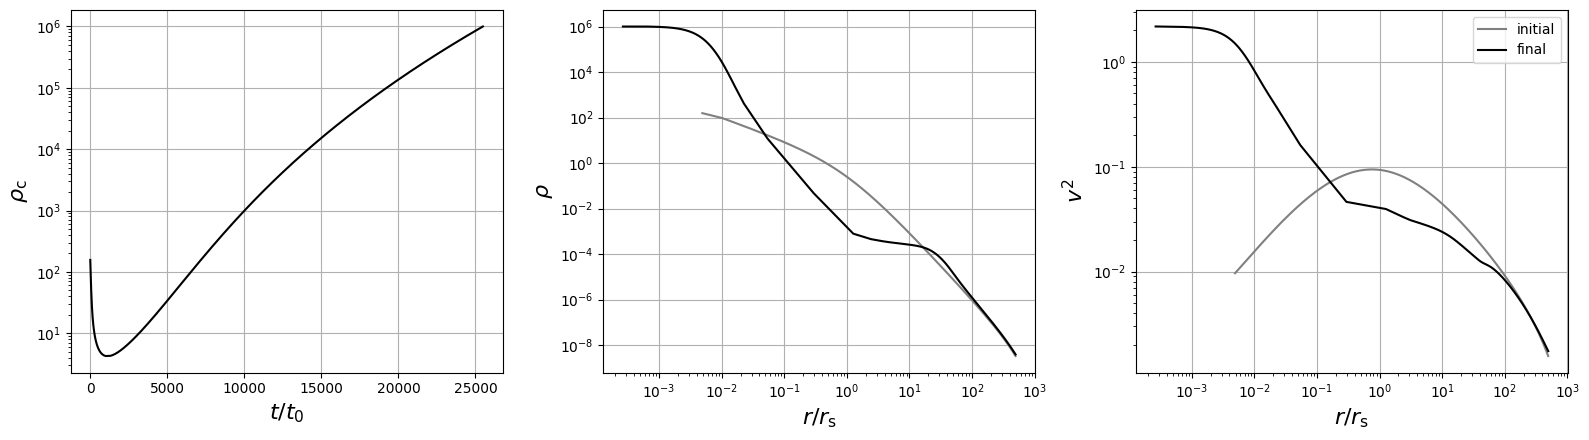

In [310]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].plot(t, rho_c, color='black')
ax[0].set_yscale('log')

ax[1].loglog(r_i, rho_i, color='grey', label='initial')
ax[1].loglog(r_f, rho_f, color='black', label='final')

ax[2].loglog(r_i, v2_i, color='grey', label='initial')
ax[2].loglog(r_f, v2_f, color='black', label='final')

for axs in ax:
    # axs.set_ylim((0.6, 1.4))
    axs.grid()

ax[0].set_xlabel(r'$t/t_0$', fontsize=16)
ax[0].set_ylabel(r'$\rho_\mathrm{c}$', fontsize=16)

ax[1].set_xlabel(r'$r/r_\mathrm{s}$', fontsize=16)
ax[1].set_ylabel(r'$\rho$', fontsize=16)

ax[2].set_xlabel(r'$r/r_\mathrm{s}$', fontsize=16)
ax[2].set_ylabel(r'$v^2$', fontsize=16)

ax[2].legend()

fig.tight_layout()